# Proof of Concept (PoC)
---

## 1.) Data Summary

**- What is the original format, structure, and approximate size of the full dataset?**

The full dataset is formated in a csv file with several GBs of data. They are partioned by years between 2018-2020 with 11 tables each. Each table is separated in parts because of how large the data is.


**- Describe the features(columns) you are working with across your selected tables.**

## 2019 Data

- Consignee

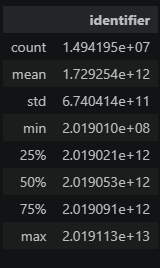

- Header

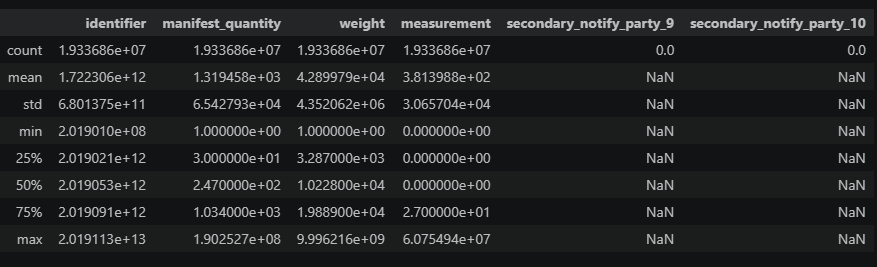


- Shipper

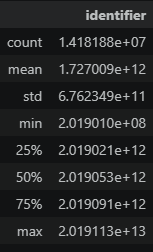


## Headers
- **identifier**: Represents a unique import order.
- **port_of_unlading**: The U.S. port where an import is unloaded.
- **foreign_port_of_lading**: The foreign port where an import is loaded for delivery.
- **weight**: The weight of an import based on its unit.
- **weight_unit**: The unit of measure for the weight.

## Shipper
- **identifier**: Represents a unique import order.
- **shipper_party_name**: The name of the shipping company.

## Consignee
- **identifier**: Represents a unique import order.
- **consignee_name**: The company that takes responsibility after the cargo has been unloaded by the shipping company.


**- Detail your data cleaning methodology:**    

**- How will you handle errors, nulls, duplicates, and outliers?**

**- What quality standards will you enforce for your Silver layer data?**

- If there are any typos, I will make sure to check the data. After which, based on what the column represents, I will replace that value with either a NULL, a zero (if the value is meaningful), or impute a statistical value(mean/median).
- If a column has a significant amount of null/blank values, it would be my best judgement to remove that column to reduce redundancy.
- To check if there are any duplicates, I will make sure if there an imports that have the same identifier. Since identitifer is a primary key, it's important to ensure the constraint is processing correctly. In turns of actually manipulating, I would discard one or the other.
- To handle outliers, I will either keep them if it makes sense, correct it if there was a typo/wrong unit, or completely remove them.


- In my Silver layer data, I will enforce the schemas of each tables such as the primary key and data types, make sure there are no duplicate primary keys, and standarize the units for quantitative measurements.

**- Does the data need to be augmented with any external sources? If so, what and why?**

The data does not need to be augmented with any external sources, because the data that is already present is sufficient enough to solve my use case.

---

## 2.) Proposed Solution

**- A complete Entity Relationship Diagram (ERD) of your Silver layer normalized schema.**

ams_header {

    identifier int pk,
    port_of_unlading varchar(25),
    foreign_port_of_lading varchar(25),
    weight int,
    weight_unit varchar(10)

}

ams_shipper {

    identifier int pk,
    shipper_party_name varchar(25),

    ams_shipper.identifier fk references ams_header(identifier)

}

ams_consignee {

    identifier int pk,
    consignee_name varchar(25)

    ams_consignee.identifier fk references ams_header(identifier)

}

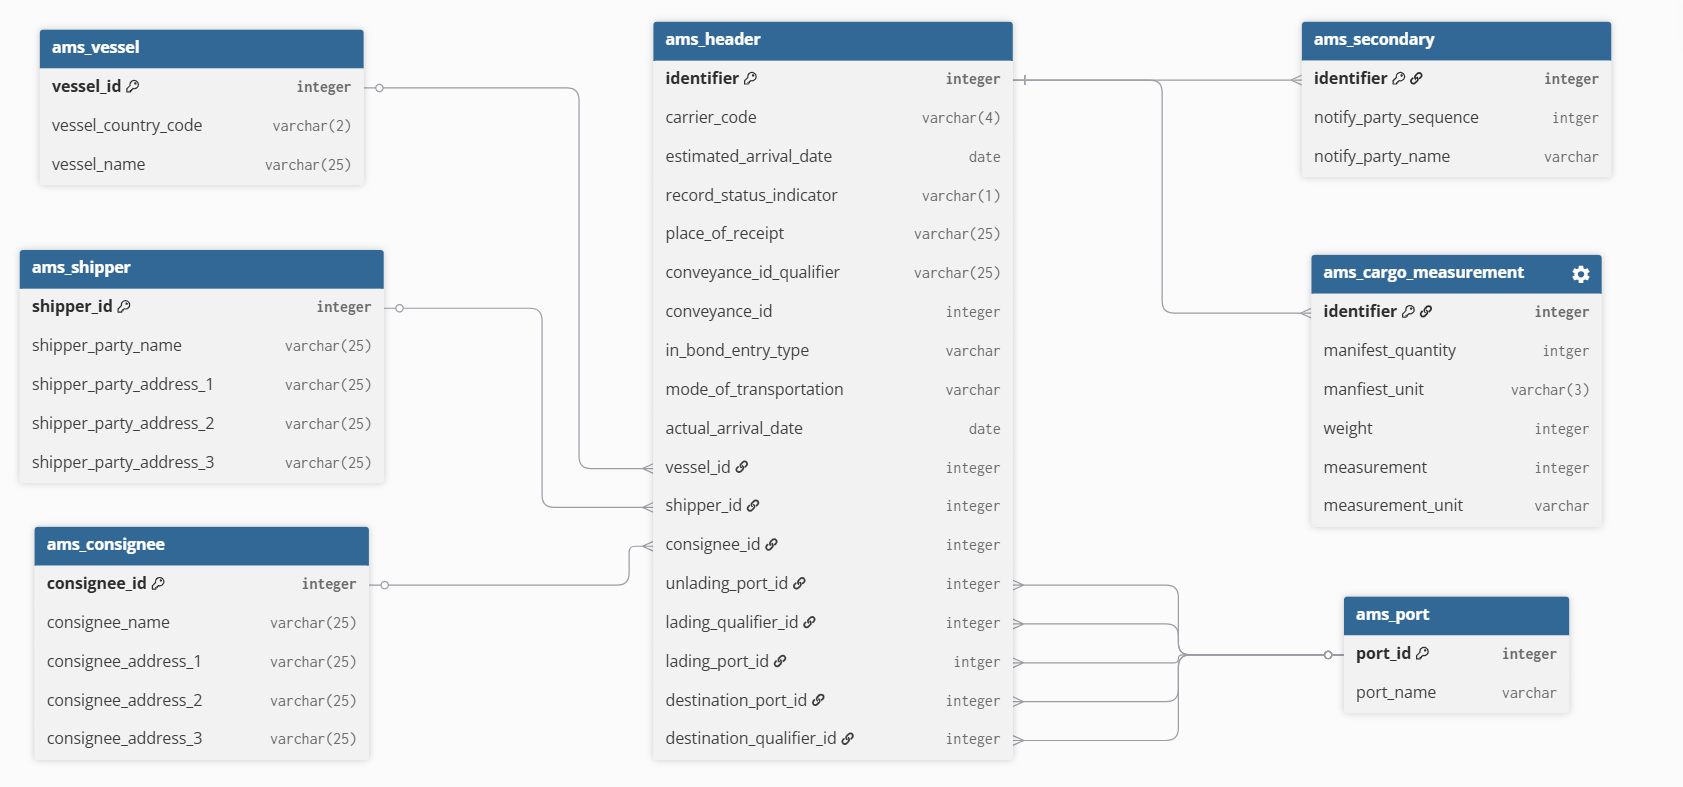

**- A description of your Gold layer design: what tables/views exist, how are they denormalized, and how do they support your use case?**

Views:

- Top U.S. ports that receive imports.
- Top foreign countries that ship to the U.S.
- Top shipping companies that ship to the U.S.
- Top consignee companies that handle imports after unloading by ships.
- Show weights of top U.S. ports.

**- Your file/directory structure for the Bronze and Silver layers on disk.**

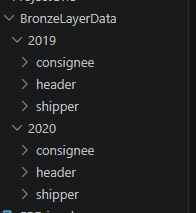

(The silver layer will be in similar data structure)

**- Your partitioning strategy for the dataset (e.g., by date, by port, etc.)**

In my case, I would partition based on year. 

---

## 3.) Use Case

- Choose or Define Your Analystical Use Case:

- You may define your own analytical use case for the Gold layer, or use the default:
    - Default: provide aggregated analysis on the breakdown of shipping activity for major U.S. ports - segmented by type of goods, country of origin, carrier, and time period.

- Must work with at least 3 of the 10 source tables and include data from more than one year.

My Use case:

- Analyze U.S. import activity across 2019-2020 to identify which major ports, countries of origin, shipping companies. and consignee companies account for the largest volumes of incoming shipments.

---

In [2]:
import pandas as pd

In [3]:
import glob

In [7]:
pd.set_option('display.max_columns', None)

headerDf = pd.read_csv("BronzeLayerData/2019/header/ams__header_2019__202001080000_part_0.csv")

headerDf

C:\Users\EF782XL\AppData\Local\Temp\ipykernel_23652\377338683.py:3: DtypeWarning: Columns (0: secondary_notify_party_3, 1: secondary_notify_party_4, 2: secondary_notify_party_5, 3: secondary_notify_party_6, 4: secondary_notify_party_7, 5: secondary_notify_party_8) have mixed types. Specify dtype option on import or set low_memory=False.
  headerDf = pd.read_csv("BronzeLayerData/2019/header/ams__header_2019__202001080000_part_0.csv")


,identifier,carrier_code,vessel_country_code,vessel_name,port_of_unlading,estimated_arrival_date,foreign_port_of_lading_qualifier,foreign_port_of_lading,manifest_quantity,manifest_unit,weight,weight_unit,measurement,measurement_unit,record_status_indicator,place_of_receipt,port_of_destination,foreign_port_of_destination_qualifier,foreign_port_of_destination,conveyance_id_qualifier,conveyance_id,in_bond_entry_type,mode_of_transportation,secondary_notify_party_1,secondary_notify_party_2,secondary_notify_party_3,secondary_notify_party_4,secondary_notify_party_5,secondary_notify_party_6,secondary_notify_party_7,secondary_notify_party_8,secondary_notify_party_9,secondary_notify_party_10,actual_arrival_date
0,201901010,OOLU,FR,CMA CGM FIGARO,"Oakland, California",2017-10-08,Schedule K Foreign Port,"Tanjung Priok,Indonesia",834,PCS,9904,Kilograms,0,Cubic Meters,Deleted,JAKARTA,NaN,NaN,NaN,IMO Number/Lloyds Number,9450600,NaN,"Vessel, containerized",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2017-10-10
1,201901011,AEHS,JP,MOL COMMITMENT,"Los Angeles, California",2018-01-28,Schedule K Foreign Port,"Singapore,Singapore",60,PKG,857,Kilograms,0,NaN,Deleted,MUMBAI,NaN,NaN,NaN,Conveyance Name,MOL COMMITMENT,NaN,"Vessel, containerized",MOLU,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2018-01-30
2,201901012,EXDO,PA,EVER LUCKY,"Norfolk, Virginia",2018-03-28,Schedule K Foreign Port,"Rotterdam,Netherlands",3350,PKG,44599,Kilograms,12756,Cubic Meters,Amended,GDYNIA,NaN,NaN,NaN,IMO Number/Lloyds Number,9604172,NaN,"Vessel, containerized",APLU,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2018-03-30
3,201901013,EXDO,PA,EVER LUCKY,"Norfolk, Virginia",2018-03-28,Schedule K Foreign Port,"Bremerhaven,Federal Republic of Germany",642,PKG,9258,Kilograms,2539,Cubic Meters,Amended,GDYNIA,NaN,NaN,NaN,IMO Number/Lloyds Number,9604172,NaN,"Vessel, containerized",APLU,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2018-03-30
4,201901014,EXDO,PA,EVER LUCKY,"Norfolk, Virginia",2018-03-28,Schedule K Foreign Port,"Bremerhaven,Federal Republic of Germany",2743,CTN,34760,Kilograms,136,Cubic Meters,Amended,BREMERHAVEN,NaN,NaN,NaN,IMO Number/Lloyds Number,9604172,NaN,"Vessel, containerized",APLU,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2018-03-30
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4999995,2019040621908,FTNV,HK,MOL BRILLIANCE,"Long Beach, California",2019-04-01,Schedule K Foreign Port,"Hong Kong,Hong Kong",55,CTN,1097,Kilograms,1,Cubic Meters,New,HK,NaN,NaN,NaN,Conveyance Name,MOL BRILLIANCE,NaN,"Vessel, containerized",YMLU,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2019-04-05
4999996,2019040621909,ONEY,HK,MOL BRILLIANCE,"Long Beach, California",2019-04-04,Schedule K Foreign Port,"Hong Kong,Hong Kong",1260,PKG,12485,Kilograms,57,Cubic Meters,New,HONG KONG,"Hidalgo, Texas",NaN,NaN,IMO Number/Lloyds Number,9685334,Immediate Transportation (IT),"Vessel, non-container",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2019-04-05
4999997,2019040621910,HYSL,HK,MOL BRILLIANCE,"Long Beach, California",2019-04-02,Schedule K Foreign Port,"Yantian,China (Mainland)",825,CTN,4366,Kilograms,0,NaN,New,YANTIAN,NaN,NaN,NaN,Conveyance Name,MOL BRILLIANCE,NaN,"Vessel, containerized",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2019-04-05
4999998,2019040621911,HEIC,PA,BANGKOK BRIDGE,"Long Beach, California",2019-04-03,Schedule K Foreign Port,"Kobe,Japan",590,CTN,7578,Kilograms,0,NaN,New,KOBE,NaN,NaN,NaN,Conveyance Name,BANGKOK BRIDGE,NaN,"Vessel, containerized",YMLU,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2019-04-05


In [ ]:
# Path to the Bronze Layer data for consignee in 2019
path = 'BronzeLayerData/2019/consignee/'

# Get all CSV files in the directory
files = glob.glob(path + '*.csv')

# Read each CSV into a DataFrame and store in a list
dfs = [pd.read_csv(f) for f in files]

# Concatenate all DataFrames into one
consignee_data_2019 = pd.concat(dfs, ignore_index=True)

consignee_data_2019.describe()

,identifier
count,1.494195e+07
mean,1.729254e+12
std,6.740414e+11
min,2.019010e+08
25%,2.019021e+12
50%,2.019053e+12
75%,2.019091e+12
max,2.019113e+13


In [10]:
# Path to the Bronze Layer data for header in 2019
path = 'BronzeLayerData/2019/header/'

# Get all CSV files in the directory
files = glob.glob(path + '*.csv')

# Read each CSV into a DataFrame and store in a list
dfs = [pd.read_csv(f) for f in files]

# Concatenate all DataFrames into one
header_data_2019 = pd.concat(dfs, ignore_index=True)

header_data_2019.describe()

C:\Users\EF782XL\AppData\Local\Temp\ipykernel_16668\3796520877.py:8: DtypeWarning: Columns (0: secondary_notify_party_3, 1: secondary_notify_party_4, 2: secondary_notify_party_5, 3: secondary_notify_party_6, 4: secondary_notify_party_7, 5: secondary_notify_party_8) have mixed types. Specify dtype option on import or set low_memory=False.
  dfs = [pd.read_csv(f) for f in files]
C:\Users\EF782XL\AppData\Local\Temp\ipykernel_16668\3796520877.py:8: DtypeWarning: Columns (0: secondary_notify_party_3, 1: secondary_notify_party_4, 2: secondary_notify_party_5, 3: secondary_notify_party_6) have mixed types. Specify dtype option on import or set low_memory=False.
  dfs = [pd.read_csv(f) for f in files]


,identifier,manifest_quantity,weight,measurement,secondary_notify_party_9,secondary_notify_party_10
count,1.933686e+07,1.933686e+07,1.933686e+07,1.933686e+07,0.0,0.0
mean,1.722306e+12,1.319458e+03,4.289979e+04,3.813988e+02,NaN,NaN
std,6.801375e+11,6.542793e+04,4.352062e+06,3.065704e+04,NaN,NaN
min,2.019010e+08,1.000000e+00,1.000000e+00,0.000000e+00,NaN,NaN
25%,2.019021e+12,3.000000e+01,3.287000e+03,0.000000e+00,NaN,NaN
50%,2.019053e+12,2.470000e+02,1.022800e+04,0.000000e+00,NaN,NaN
75%,2.019091e+12,1.034000e+03,1.988900e+04,2.700000e+01,NaN,NaN
max,2.019113e+13,1.902527e+08,9.996216e+09,6.075494e+07,NaN,NaN


In [ ]:
# Path to the Bronze Layer data for shipper in 2019
path = 'BronzeLayerData/2019/shipper/'

# Get all CSV files in the directory
files = glob.glob(path + '*.csv')

# Read each CSV into a DataFrame and store in a list
dfs = [pd.read_csv(f) for f in files]

# Concatenate all DataFrames into one
shipper_data_2019 = pd.concat(dfs, ignore_index=True)

shipper_data_2019.describe()

,identifier
count,1.418188e+07
mean,1.727009e+12
std,6.762349e+11
min,2.019010e+08
25%,2.019021e+12
50%,2.019053e+12
75%,2.019091e+12
max,2.019113e+13
